In [2]:
import os
import glob
import re
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
# Load your Excel-edited CSV benchmark file
df_benchmark = pd.read_csv("experiments24-7.csv")

# Convert it into a clean list of dictionaries for your loop
BENCHMARK_CONFIG = df_benchmark.to_dict(orient="records")

# Preview the loaded experiments
print(f"Loaded {len(BENCHMARK_CONFIG)} experiments from CSV!")
display(df_benchmark[["id", "domain", "subprompt_1", "subprompt_2", "seed", "base_prompt", "test_focus"]])

Loaded 20 experiments from CSV!


,id,domain,subprompt_1,subprompt_2,seed,base_prompt,test_focus
0,typo_01,Typography,make font serif,make stroke thicker,101,the word 'THESIS' written in clean bold white ...,Geometric continuity and sharp edge preservation
1,typo_02,Typography,make the text stroke thicker,make the neon glow brighter,102,"a neon sign spelling 'OPEN' on a brick wall, h...",Local geometry vs global illumination disentan...
2,typo_03,Typography,make the letter italic,add decorative flourishes,103,a minimal logo of the letter 'A' on a white ba...,Shear and affine transformation monotonicity
3,typo_04,Typography,make font gothic blackletter,make text three dimensional,104,the word 'DESIGN' printed in clean minimalist ...,Complex typographic style transition and depth...
4,typo_05,Typography,make letter spacing wider,add drop shadow effect,105,the single word 'SLIDER' in bold uppercase mod...,Kerning and spatial separation vs shadow casting
5,fashion_01,Fashion,make garment denim,make the shirt oversized,201,a fashion model wearing a plain cotton crewnec...,Texture vs silhouette disentanglement
6,fashion_02,Fashion,make blazer longer,add gold buttons,202,full body shot of a woman wearing a tailored f...,Boundary and occlusion continuity
7,fashion_03,Fashion,make high-top,make the sole thicker platform,203,"a casual sneaker on a plain white background, ...",Structural deformations and proportion scaling
8,fashion_04,Fashion,make dress silk satin texture,make dress floral patterned,204,a minimalist elegant evening gown on a mannequ...,Surface reflectivity vs complex pattern overlay
9,fashion_05,Fashion,add leather jacket over shirt,make jeans distressed torn,205,streetwear fashion model wearing plain t-shirt...,Layering addition vs local material destruction


# GSTLoRA

In [ ]:
def display_1d_sweep(target_filename_sample, output_dir="./outputs/gstlora"):
    if not os.path.exists(output_dir):
        print(f"Directory '{output_dir}' does not exist.")
        return []

    raw_name = os.path.basename(target_filename_sample).replace(".png", "")
    
    # 1. Convert numerical values to wildcard search pattern
    search_pattern = re.sub(r'(-?\d+(\.\d+)?)', '*', raw_name) + ".png"
    search_path = os.path.join(output_dir, search_pattern)

    matching_files = glob.glob(search_path)
    if not matching_files:
        search_pattern = re.sub(r'alpha_-?\d+(\.\d+)?', 'alpha_*', raw_name) + ".png"
        matching_files = glob.glob(os.path.join(output_dir, search_pattern)) # might have to edit relative path because notebook was moved into experiments folder

    if not matching_files:
        print(f"No matching images found for pattern: {search_pattern}")
        return []

    # 2. Extract alpha float helper
    def extract_alpha(filepath):
        match = re.search(r'(-?\d+\.\d+|-?\d+)(?=\.png$)', filepath)
        return float(match.group(1)) if match else 0.0

    matching_files = sorted(matching_files, key=extract_alpha)

    # Clean instruction prompt
    clean_prompt_name = re.sub(r'(_alpha)?_-?\d+(\.\d+)?$', '', raw_name)
    instruction = clean_prompt_name.replace("_", " ").title()

    # 3. Render grid via Matplotlib figure
    num_images = len(matching_files)
    fig, axes = plt.subplots(1, num_images, figsize=(3 * num_images, 3.5))
    
    # Handle single image case
    if num_images == 1:
        axes = [axes]

    for ax, filepath in zip(axes, matching_files):
        img = Image.open(filepath)
        alpha_val = extract_alpha(filepath)
        
        ax.imshow(img)
        # Using Matplotlib's native LaTeX rendering!
        ax.set_title(rf"$\alpha = {alpha_val:+.1f}$", fontsize=14, pad=8)
        ax.axis('off')

    plt.suptitle(f'Editing Instruction: "{instruction}"', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()
    
    return matching_files

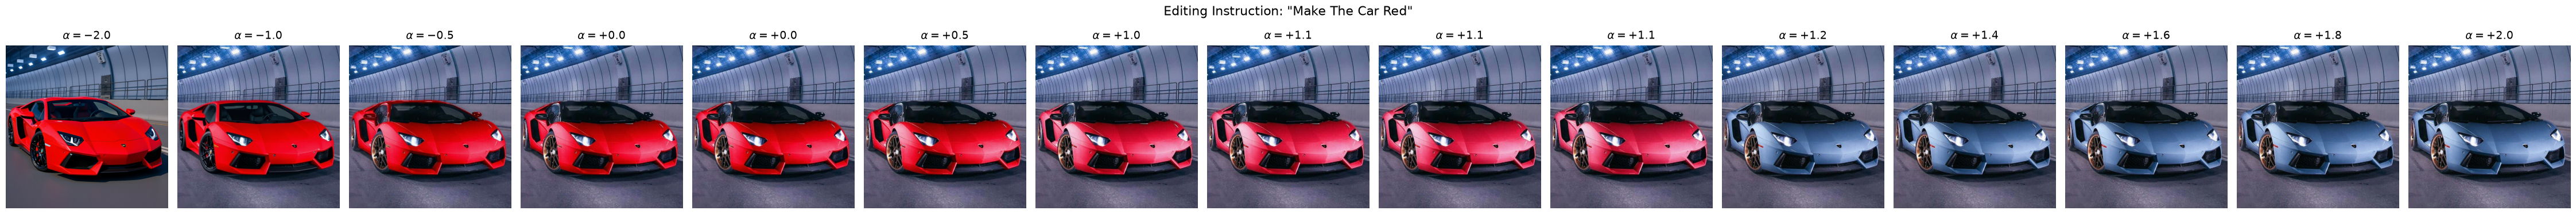

In [25]:
sample = "make_the_car_red_alpha_0.5.png"
matched_paths = display_1d_sweep(sample, output_dir="./outputs/gstlora")

# STLoRA

In [21]:
def display_2d_stlora_matrix(target_filename_sample, output_dir="./outputs/stlora"):
    """
    Parses a sample 2D STLoRA filename (e.g., 'make_background_red_-1.0_make_branches_thicker_2.0.png'),
    finds all matching grid outputs, and renders them as a 2D matrix with subprompt titles and LaTeX alpha axis labels.
    """
    if not os.path.exists(output_dir):
        print(f"Directory '{output_dir}' does not exist.")
        return []

    basename = os.path.basename(target_filename_sample).replace(".png", "")

    # 1. Regex to extract the two subprompts and their values
    # Matches: <subprompt1>_<val1>_<subprompt2>_<val2>
    pattern = r"^(.*?)(_[-+]?\d+(?:\.\d+)?)_(.*?)(_[-+]?\d+(?:\.\d+)?)$"
    match = re.match(pattern, basename)

    if not match:
        print(f"Filename '{basename}' does not match expected pattern '<subprompt1>_<val1>_<subprompt2>_<val2>'.")
        return []

    subprompt1 = match.group(1).replace("_", " ").title()
    subprompt2 = match.group(3).replace("_", " ").title()

    # Build glob wildcard pattern replacing float values with *
    # Resulting pattern: subprompt1_*_subprompt2_*.png
    glob_pattern = f"{match.group(1)}_*_{match.group(3)}_*.png"
    search_path = os.path.join(output_dir, glob_pattern)
    matching_files = glob.glob(search_path)

    if not matching_files:
        print(f"No matching files found for pattern: {glob_pattern}")
        return []

    # 2. Extract (alpha1, alpha2) for each file
    file_data = []
    for filepath in matching_files:
        filename = os.path.basename(filepath).replace(".png", "")
        m = re.match(pattern, filename)
        if m:
            val1 = float(m.group(4).lstrip("_"))
            val2 = float(m.group(2).lstrip("_"))
            file_data.append((val1, val2, filepath))

    # 3. Organize into grid coordinates
    alpha1_vals = sorted(list(set(d[1] for d in file_data)))  # Rows (Subprompt 1)
    alpha2_vals = sorted(list(set(d[0] for d in file_data)))  # Cols (Subprompt 2)

    rows, cols = len(alpha1_vals), len(alpha2_vals)
    print(f"Found {len(file_data)} images for a {rows}x{cols} matrix sweep.")

    # Create map from (val1, val2) -> filepath
    grid_map = {(d[1], d[0]): d[2] for d in file_data}

    # 4. Render 2D Matplotlib Grid
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

    for r, a1 in enumerate(alpha1_vals):
        for c, a2 in enumerate(alpha2_vals):
            # Handle single row/col edge cases for axes indexing
            if rows == 1 and cols == 1:
                ax = axes
            elif rows == 1:
                ax = axes[c]
            elif cols == 1:
                ax = axes[r]
            else:
                ax = axes[r, c]

            filepath = grid_map.get((a1, a2))
            if filepath and os.path.exists(filepath):
                img = Image.open(filepath)
                ax.imshow(img)

            ax.axis("off")

            # Label top column headers (Subprompt 2 / Alpha 2)
            if r == 0:
                ax.set_title(rf"$\alpha_1 = {a2:+.1f}$", fontsize=12, pad=6)

            # Label left row headers (Subprompt 1 / Alpha 1)
            if c == 0:
                ax.text(
                    -0.12, 0.5, rf"$\alpha_2 = {a1:+.1f}$",
                    transform=ax.transAxes,
                    va='center', ha='right',
                    fontsize=12, rotation=0
                )

    # Main titles indicating which subprompt corresponds to alpha_1 vs alpha_2
    plt.suptitle(
        f'2D Matrix Edit Sweep\n'
        f'X-Axis ($\\alpha_1$): "{subprompt1}"  |  Y-Axis ($\\alpha_2$): "{subprompt2}"',
        fontsize=14, y=1.02
    )
    plt.tight_layout()
    plt.show()

    return matching_files

Found 9 images for a 3x3 matrix sweep.


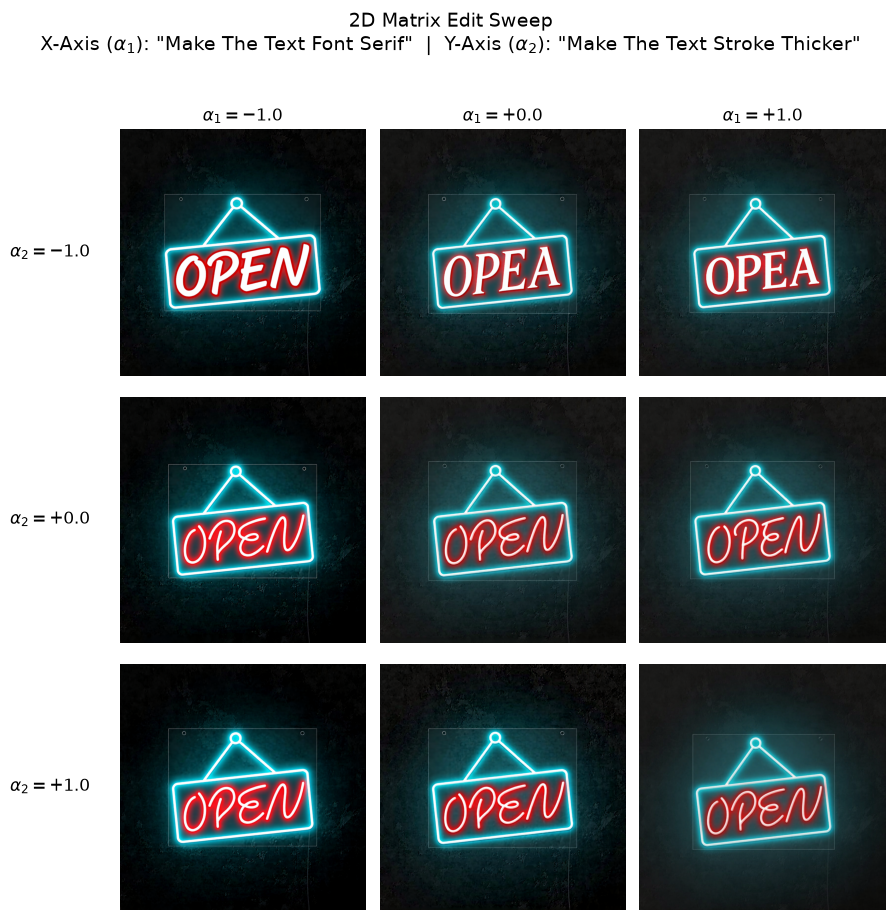

In [23]:
sample = "make_the_text_font_serif_-1.0_make_the_text_stroke_thicker_-1.0.png"
matched_paths = display_2d_stlora_matrix(sample, output_dir="./outputs/stlora")